P50: 8 недель
P70: 9 недель
P85: 10 недель
P95: 11 недель


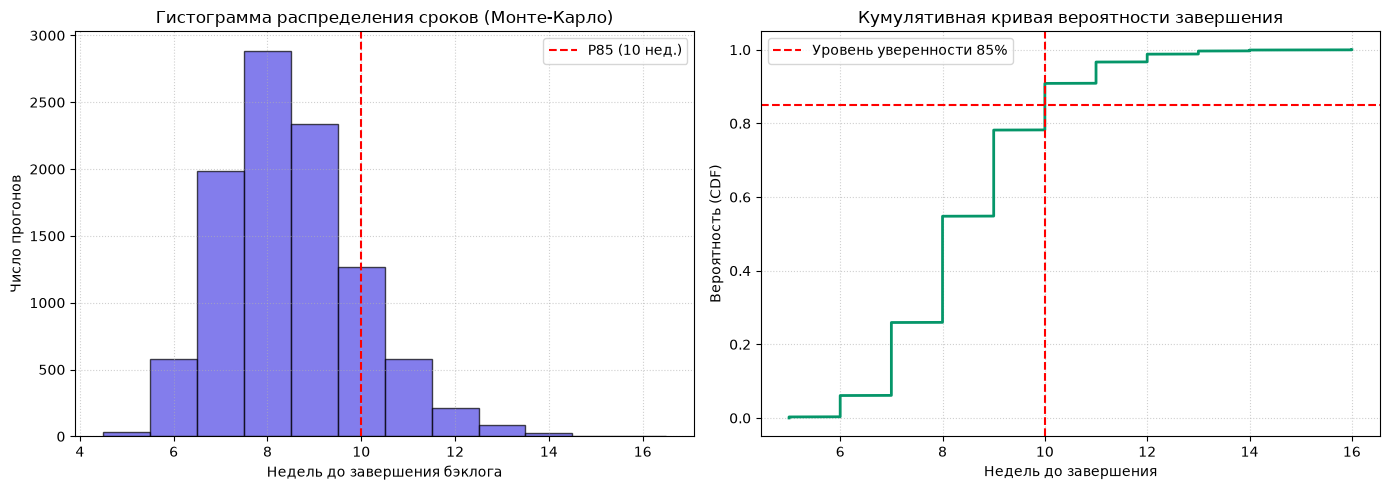

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Фиксация генератора для воспроизводимости
rng = np.random.default_rng(42)

# Исторические данные темпа закрытия задач
history = np.array([4, 6, 0, 7, 5, 2, 6, 9, 4, 5, 0, 6, 7, 4, 5, 1, 6, 5, 9, 3, 4, 6, 5, 8, 2, 5])
BACKLOG = 38
RUNS = 10_000

weeks = np.empty(RUNS, dtype=int)
for i in range(RUNS):
    done, w = 0, 0
    while done < BACKLOG:
        done += rng.choice(history)
        w += 1
    weeks[i] = w

# Расчет квантилей распределения
p50 = np.percentile(weeks, 50)
p70 = np.percentile(weeks, 70)
p85 = np.percentile(weeks, 85)
p95 = np.percentile(weeks, 95)

print(f"P50: {p50:.0f} недель")
print(f"P70: {p70:.0f} недель")
print(f"P85: {p85:.0f} недель")
print(f"P95: {p95:.0f} недель")

# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма распределения сроков
bins = range(weeks.min(), weeks.max() + 2)
ax1.hist(weeks, bins=bins, align='left', color='#4F46E5', edgecolor='black', alpha=0.7)
ax1.axvline(p85, color='red', linestyle='--', label=f'P85 ({p85:.0f} нед.)')
ax1.set_title('Гистограмма распределения сроков (Монте-Карло)')
ax1.set_xlabel('Недель до завершения бэклога')
ax1.set_ylabel('Число прогонов')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Кумулятивная кривая вероятности
sorted_weeks = np.sort(weeks)
cumulative_prob = np.arange(1, RUNS + 1) / RUNS
ax2.plot(sorted_weeks, cumulative_prob, color='#059669', linewidth=2)
ax2.axhline(0.85, color='red', linestyle='--', label='Уровень уверенности 85%')
ax2.axvline(p85, color='red', linestyle='--')
ax2.set_title('Кумулятивная кривая вероятности завершения')
ax2.set_xlabel('Недель до завершения')
ax2.set_ylabel('Вероятность (CDF)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()